<table style="width: 100%; border-style: none;">
<tr style="border-style: none">
<td style="border-style: none; width: 1%; text-align: left; font-size: 16px">Institut f&uuml;r Theoretische Physik<br /> Universit&auml;t zu K&ouml;ln</td>
<td style="border-style: none; width: 1%; font-size: 16px">&nbsp;</td>
<td style="border-style: none; width: 1%; text-align: right; font-size: 16px">Prof. Dr. Matteo Rizzi

</tr>
</table>
<hr>
<h1 style="font-weight:bold; text-align: center; margin: 0px; font-size: 30px; padding:0px;">Computerphysik</h1>
<h1 style="font-weight:bold; text-align: center; margin: 0px; font-size: 30px; padding:0px;">Übungsblatt 6</h1>
<hr>
<h3 style="font-weight:bold; text-align: center; margin: 0px; font-size: 20px; padding:0px; margin-bottom: 20px;">Sommersemester 2026</h3>
<hr>

<table style="border-style: none; width: 100%"><tr style="border-style: none;">
<td style="border-style: none; width: 1%; text-align: left; font-size: 25px; font-weight: bold; text-decoration: underline">Aufgaben auf Übungsblatt 6</td>
<td style="border-style: none; width: 1%; text-align: right; font-size: 15px"></td></tr></table>

- **Aufgabe 06_01: Sonne und Erde**
- Aufgabe 06_02: Pendel

Diese Woche werden Sie verschiedene Modellsysteme und ihre Differentialgleichungen, sowie verschiedene Algorithmen zur numerischen Lösung ebendieser betrachten.
Nach Bearbeitung dieser Probleme sollten Sie ein gutes Gefühl dafür entwickelt haben, wie DGL implementiert werden können und wann welche Lösungsansätze angebracht sind.

<table style="border-style: none; width: 100%"><tr style="border-style: none;">
<td style="border-style: none; width: 1%; text-align: left; font-size: 25px; font-weight: bold; text-decoration: underline"> Zwei Körper mit dem expliziten Eulerverfahren</td>


In dieser Aufgabe sollen Sie ein einfaches Zweikörperproblem betrachten: Die Erde kreist in **2D** um die Sonne.

Es soll nun die Umlaufbahn der Erde um die Sonne im Verlauf von 10 Jahren errechnet und dargestellt werden. Dazu werden folgende Bausteine benötigt:

1. Speicherplatz für die Messwerte zu jedem Zeitpunkt reservieren
2. Die beiden Körper initialisieren (also Startbedingungen wählen)
3. Die durch Gravitation ausgelöste Beschleunigung der beiden Körper berechnen
4. Mit dem Forward-Euler-Verfahren die Zeitentwicklung bestimmen

Für die ersten beiden Schritte haben Sie bereits einen Vorschrieb in der nächsten Zelle gegeben.

> **WICHTIG**: Datenstrukturen wie die hier vorgegebene sind nicht für jeden gleich angenehm zum Auslesen oder Beschreiben. <br />
> Fühlen Sie sich also frei, z.B. Arrays für jeweils x- und y-Koordinaten zu definieren, um nur eindimensionale Arrays zu haben, <br />
> oder auch größere Datenstrukturen zu wählen (ein Array, in dem alle Daten für Sonne/Erde drin sind) oder sogar Dictionaries. <br />

In [2]:
AU = 1.496e11                   # Eine Astronomische Einheit in Metern
sJahr = 365.2425 * 24 * 3600    # Anzahl Sekunden im Jahr

T = 10 * sJahr                  # 10 Jahre in Sekunden
N = 2000                        # Anzahl Simulationsschritte
dt = T/N                        # Bestimmung der Schrittgröße
t = 0:dt:T-dt                   # Zeitschritte in Sekunden


# Speicherplatz reservieren:

pos_s = Array{Float64}(undef,N,2)   # Positionen der Sonne
pos_e = Array{Float64}(undef,N,2)   # Positionen der Erde

v_s = Array{Float64}(undef,N,2)   # Geschwindigkeiten der Sonne
v_e = Array{Float64}(undef,N,2)   # Geschwindigkeiten der Erde

a_s = Array{Float64}(undef,N,2)   # Geschwindigkeiten der Sonne
a_e = Array{Float64}(undef,N,2)


#Körper initialisieren:

m_s = 1.989e30  # Masse der Sonne in kg
m_e = 5.972e24  # Masse der Erde in kg

pos_s[1,:] = [0,0]  # Startposition der Sonne in m
pos_e[1,:] = [AU,0] # Startposition der Erde in m

v_s[1,:] = [0,0]              # Startgeschwindigkeiten der Sonne in m/s
v_e[1,:] = [0,2*pi*AU/sJahr]  # Startgeschwindigkeiten der Erde in m/s

2-element Vector{Float64}:
     0.0
 29786.289941882413

### a) Mit der Datenstruktur vertraut machen
Nachdem Sie sich für eine Datenstruktur entschieden (oder die vorliegende übernommen) haben, erklären Sie wo welche Daten abgespeichert werden. Geben Sie einmal die Startposition und Geschwindigkeit der Erde als getrennte Koordinaten aus.
Erklären Sie die vorgegebenen Startbedingungen.

In [3]:
using LinearAlgebra
G= 6.67e-11

6.67e-11

### b) Beschleunigung berechnen

Schreiben Sie eine Funktion, welche die aktuellen Positionen der Sonne und Erde übergeben bekommt und die beiden Beschleunigungen zurückgibt.

**Hinweis:** $\ddot{\vec{r_i}} = \sum_{j \neq i} -G \cdot m_j \cdot \frac{\vec{r_i}-\vec{r_j}}{|\vec{r_i}-\vec{r_j}|^3}$

In [5]:
function beschleunigung(n)
    
    a_e = -G*m_s*(pos_e[n,:]-pos_s[n,:])/norm(pos_e[n,:]-pos_s[n,:])^3
    a_s = G*m_e*(pos_e[n,:]-pos_s[n,:])/norm(pos_e[n,:]-pos_s[n,:])^3
    return a_e , a_s
end

beschleunigung (generic function with 1 method)

### c) Zeitentwicklung bestimmen

Implementieren Sie das explizite Eulerverfahren um die Positionen von Sonne und Erde Schrittweise zu bestimmen.
Für eine beliebige Größe x gilt:
$$ x[t+1] = x[t] + \dot{x}[t] \cdot dt$$

**Hinweis:** Überlegen Sie, welche Größen wir hier betrachten und was die entsprechenden zeitlichen Ableitungen sind.

Plotten Sie dann die Trajektorien von Sonne und Erde in einem gemeinsamen Koordinatensystem.

In [56]:

for i in 2:N

    #Beschleunigung
    a_e , a_s = beschleunigung(i-1)

    #Geschwindigkeit
    v_e[i,:] = v_e[i-1,:] + a_e * dt
    v_s[i,:] = v_s[i-1,:] + a_s* dt

    #Position
    pos_e[i,:] = pos_e[i-1,:] + v_e[i-1,:] * dt
    pos_s[i,:] = pos_s[i-1,:] + v_s[i-1,:] * dt
end



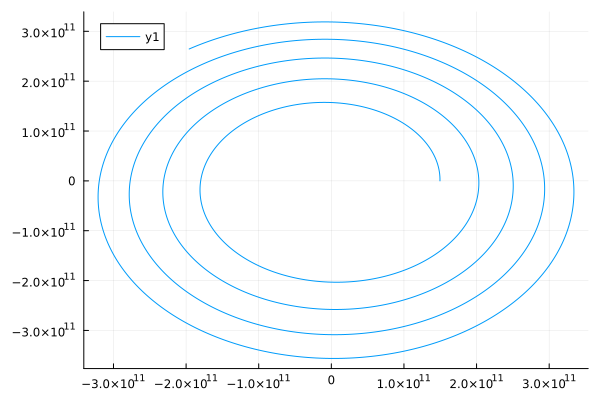

In [57]:
plot(pos_e[:,1], pos_e[:,2])


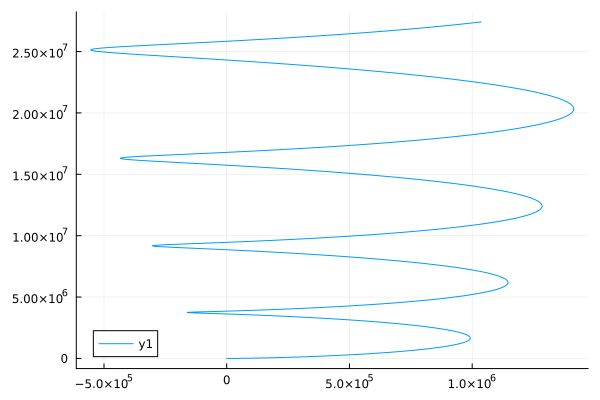

In [58]:
plot(pos_s[:,1], pos_s[:,2])

### d) Abstandsbestimmung

Bestimmen Sie den Abstand der Erde zum Startpunkt der Sonne (0/0) zu jedem Zeitpunkt und erstellen Sie anschließend einen Plot.

Betrachten Sie Ihren Plot nun zusammen mit der Trajektorie der Erde aus Aufagabenteil c). Beide erscheinen nicht korrekt. Warum?

**Hinweis**: Verfolgen Sie einzelne Eulerschritte, stellen Sie sich z.B. kleine Schrittvektoren vor.

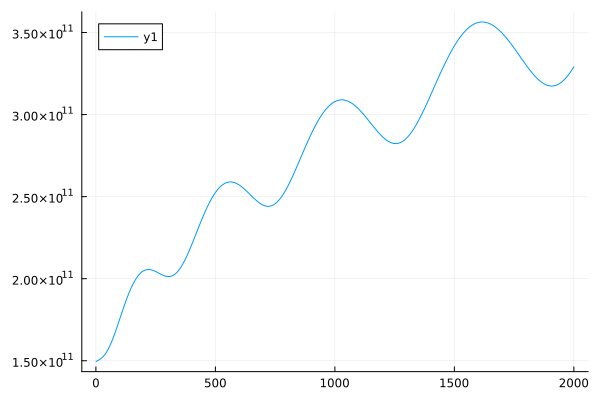

In [59]:
using Plots

Abstand = zeros(N)

for i in 1:N
    Abstand[i] = norm(pos_e[i,:]-pos_s[i,:])
end
Abstand
plot(Abstand)


### e) Energie

Berechnen Sie die Gesamtenergie der Erde (Kinetisch + Potentiell) zu jedem Zeitpunkt und erstellen Sie anschließend einen Plot. Beschreiben und erklären Sie den Verlauf. Hier wird ein fundamentales Gesetz gebrochen, welches?

In [60]:
E_kin = Array{Float64}(undef,N)
E_pot= Array{Float64}(undef,N)

for i in 1:2000
    E_kin[i] = 1/2*m_e*norm(v_e[i,:])^2
    E_pot[i] = -G*m_e*m_s/Abstand[i]
end


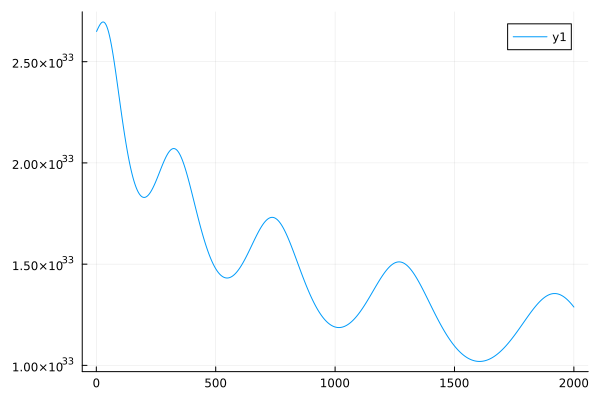

In [61]:
plot(E_kin)

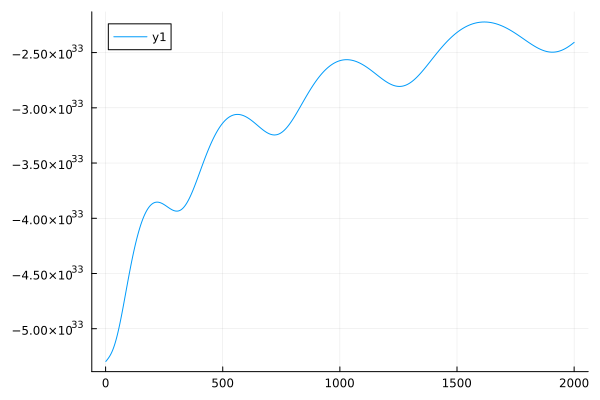

In [62]:
plot(E_pot)

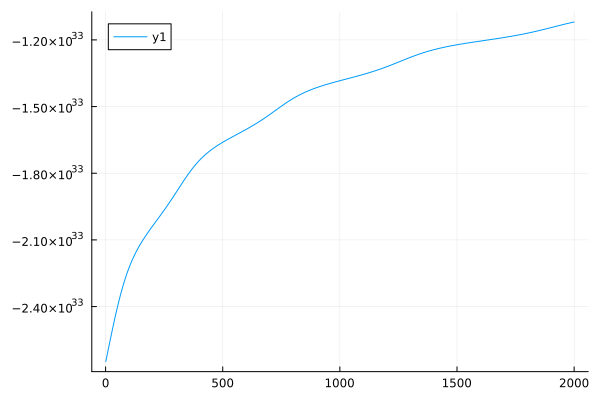

In [63]:
E_ges = E_kin + E_pot
plot(E_ges)

<table style="border-style: none; width: 100%"><tr style="border-style: none;">
<td style="border-style: none; width: 1%; text-align: left; font-size: 25px; font-weight: bold; text-decoration: underline">Der Leapfrog Algorithmus</td>
<td style="border-style: none; width: 1%; text-align: right; font-size: 15px"></td></tr></table>

Der Leapfrog Algorithmus führt einen virtuellen Zwischenschritt in das Eulerverfahren auf zwei mögliche Arten ein:

- Für einen halben Zeitschritt wird die Position mit der aktuellen Geschwindigkeit verändert (Drift), dann wird die Geschwindigkeit angepasst (Kick) und auch abgespeichert. Anschließend wird wieder für einen halben Zeitschritt die Position mit der neuen Geschwindigkeit verändert (Drift). Diese finale Position wird dann im nächsten Zeitschritt gespeichert. Dies wird Leaprog-DKD genannt.

- Analog dazu gibt es auch das Leapfrog-KDK verfahren, wo der Ablauf von Geschwindigkeits- und Ortsaktualisierung einmal vertauscht wird.

Dieser Versatz bringt für periodische Probleme viele Vorteile, wie im Verlauf der Aufgabe ersichtlich wird.

### a) Zeitentwicklung bestimmen

Schreiben Sie Ihren Code für den Euleralgorithmus nun so um, dass Sie den Versatz wie in einem der Leapfrog Verfahren implementieren. Plotten Sie anschließend wieder den Verlauf von Erde und Sonne in einem gemeinsamen Koordinatensystem.
Was fällt auf?

In [94]:


for i in 2:N

    #Position 1. Hälfte
    pos_e[i,:] = pos_e[i-1,:] + v_e[i-1,:] * dt/2
    pos_s[i,:] = pos_s[i-1,:] + v_s[i-1,:] * dt/2

    #Beschleunigung
    a_e , a_s = beschleunigung(i)

    #Geschwindigkeit
    v_e[i,:] = v_e[i-1,:] + a_e * dt
    v_s[i,:] = v_s[i-1,:] + a_s* dt

    #Position 2. Hälfte
    pos_e[i,:] += v_e[i,:] * dt/2
    pos_s[i,:] += v_s[i,:] * dt/2





end

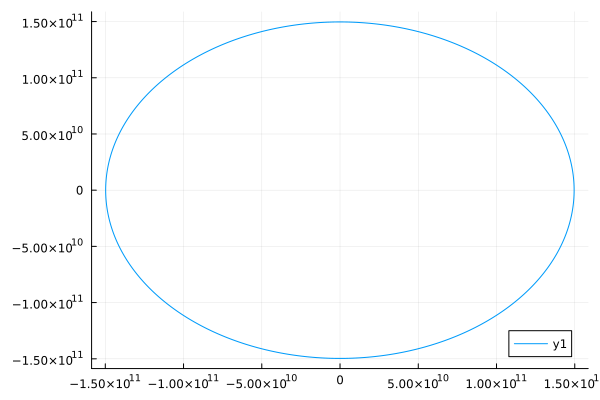

In [95]:
plot(pos_e[:,1] , pos_e[:,2])

### b) Energie [2 Punkte]

Plotten Sie Analog zur vorherigen Energiebestimmung wieder die Gesamtenergie der Erde gegen die Zeit.
Können Sie den Verlauf der Kurve erklären?

**Hinweis:** Beachten Sie die Größenordnung, auf der sich die Energie bewegt.

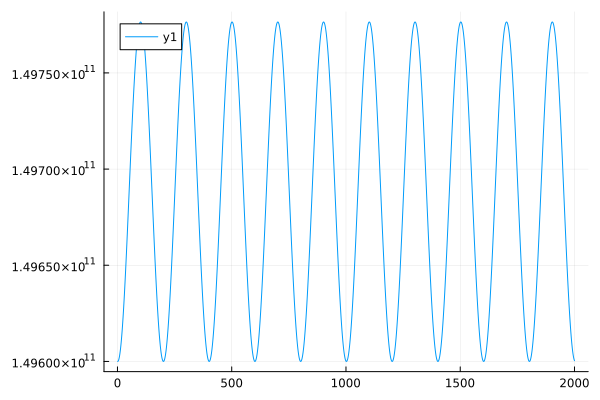

In [108]:
Abstand = zeros(N)

for i in 1:N
    Abstand[i] = norm(pos_e[i,:]-pos_s[i,:])
end
Abstand
plot(Abstand)

In [109]:
E_kin = Array{Float64}(undef,N)
E_pot= Array{Float64}(undef,N)

for i in 1:2000
    E_kin[i] = 1/2*m_e*norm(v_e[i,:])^2
    E_pot[i] = -G*m_e*m_s/Abstand[i]
end

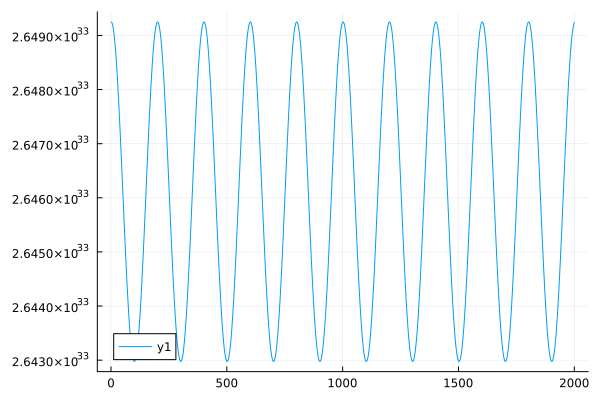

In [115]:
plot(E_kin)

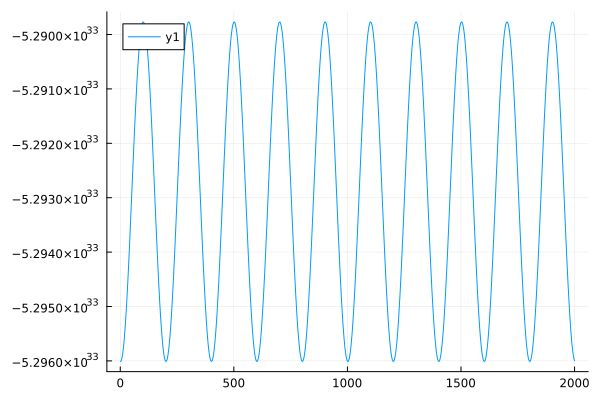

In [114]:
plot(E_pot)

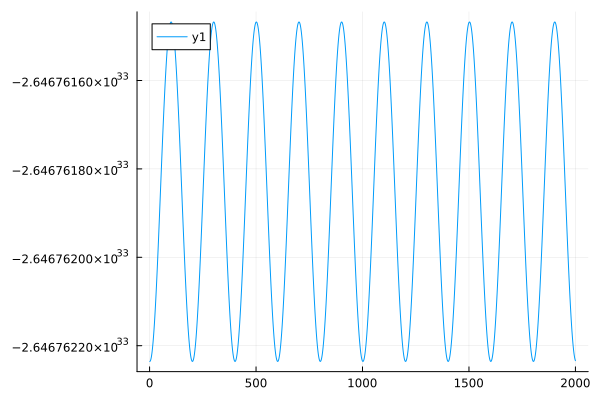

In [137]:
E = E_kin + E_pot
plot(E)

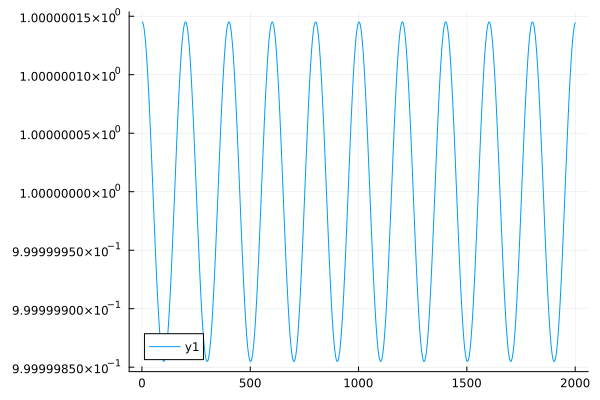

In [140]:
E_max, E_min = maximum(E) , minimum(E)

E_mittel = (E_max + E_min)/2

plot(E/E_mittel)

